# Titanic Dataset: Data Analysis, Preprocessing and Machine Learning

This notebook presents a clear, classroom-friendly machine learning workflow using the Titanic dataset.

## Main steps

1. Read the training and test datasets  
2. Perform basic data analysis  
3. Create plots using Matplotlib  
4. Extract useful information from the `Name` column  
5. Handle missing values  
6. Apply one-hot encoding to categorical columns  
7. Apply standard scaling to numerical columns  
8. Split the labelled data into training and validation sets  
9. Train Logistic Regression and Random Forest models  
10. Compare the performance of the models  

The notebook expects the following files in the same folder:

- `train.csv`
- `test.csv`


## 1. Import the Required Libraries

- **NumPy** is used for numerical operations.
- **Pandas** is used for reading, cleaning and analysing tabular data.
- **Matplotlib** is used for data visualisation.
- **Scikit-learn** is used for preprocessing, model training and evaluation.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

#pd.set_option("display.max_columns", None)

## 2. Read the Training and Test Data

The Titanic dataset is normally provided in two files:

- `train.csv` contains passenger information and the target column `Survived`.
- `test.csv` contains passenger information but does not contain `Survived`.

We use the training dataset to train and evaluate the models. After selecting a model, the test dataset can be used to generate final predictions.


In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

Training data shape: (891, 12)
Test data shape: (418, 11)


### Display the First Five Rows

`head()` allows us to see the first few records and understand how the data is organised.


In [ ]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 3. Basic Data Analysis

Before preprocessing the data, we should understand:

- the number of rows and columns;
- the type of each column;
- the numerical summary;
- the amount of missing data;
- the distribution of the target variable.


### Dataset Information

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Descriptive Statistics

`describe()` displays useful statistics for numerical columns, including:

- count;
- mean;
- standard deviation;
- minimum;
- quartiles;
- maximum.


In [ ]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Check Missing Values

Missing values must be identified because most machine learning models cannot work directly with empty values.


### Check the Target Variable

The `Survived` column contains:

- `0` for passengers who did not survive;
- `1` for passengers who survived.


In [ ]:
train_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

## 4. Data Visualisation with Matplotlib

Plots help us identify patterns that may not be obvious from tables alone.


### 4.1 Number of Survived and Non-Survived Passengers

This bar chart shows the distribution of the target variable.


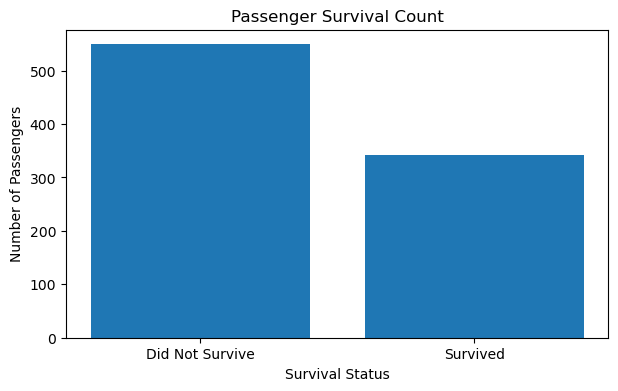

In [ ]:
survival_counts = train_df["Survived"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(["Did Not Survive", "Survived"], survival_counts.values)
plt.title("Passenger Survival Count")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.show()

### 4.2 Survival Rate by Gender

This analysis compares the average survival rate of male and female passengers.


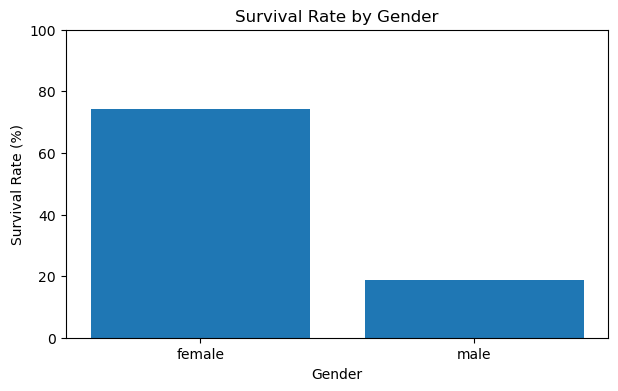

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [ ]:
gender_survival = train_df.groupby("Sex")["Survived"].mean() * 100

plt.figure(figsize=(7, 4))
plt.bar(gender_survival.index, gender_survival.values)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

gender_survival

### 4.3 Survival Rate by Passenger Class

`Pclass` represents passenger class:

- `1` = First class
- `2` = Second class
- `3` = Third class

This plot helps us investigate whether passenger class was related to survival.


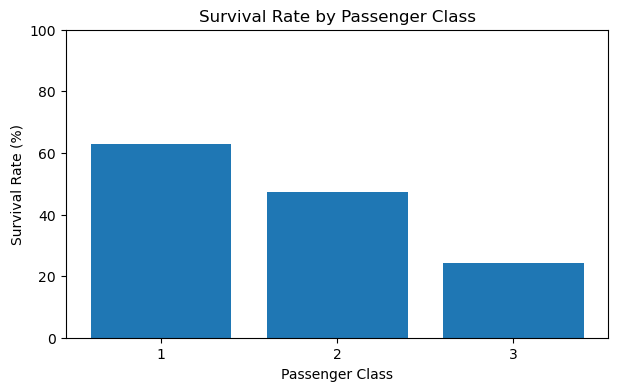

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [ ]:
class_survival = train_df.groupby("Pclass")["Survived"].mean() * 100

plt.figure(figsize=(7, 4))
plt.bar(class_survival.index.astype(str), class_survival.values)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

class_survival

### 4.4 Age Distribution

A histogram divides numerical values into intervals called bins. It helps us understand how passenger ages are distributed.


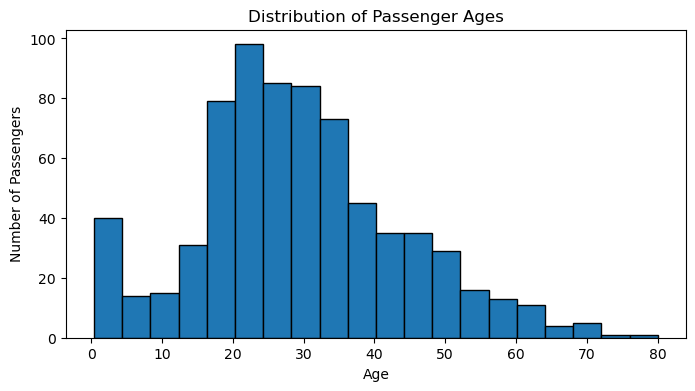

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(train_df["Age"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

### 4.5 Fare Distribution

The fare column is right-skewed because a small number of passengers paid very high fares.


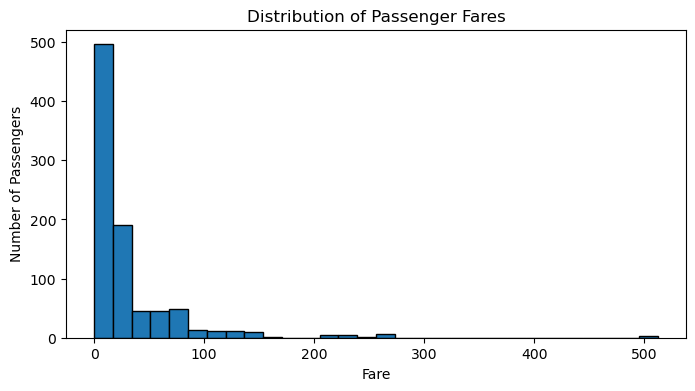

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(train_df["Fare"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Passenger Fares")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

## 5. Feature Engineering Using the Name Column

The `Name` column contains more information than only a passenger's name.

Example:

`Braund, Mr. Owen Harris`

From this text, we can extract the title `Mr`.

Titles such as `Mr`, `Mrs`, `Miss`, and `Master` may provide information about:

- gender;
- age group;
- marital status;
- social position.

We will create the following features:

- **Title**: extracted from the passenger's name;
- **NameLength**: total number of characters in the name;
- **FamilySize**: passenger plus parents, children, siblings and spouse;
- **IsAlone**: whether the passenger travelled without close family members.


In [8]:
def create_features(df):
    df = df.copy()

    # Extract the title between the comma and full stop.
    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False)
    df["Title"] = df["Title"].str.strip()

    # Replace uncommon titles with one common category.
    common_titles = ["Mr", "Mrs", "Miss", "Master"]
    df["Title"] = df["Title"].where(
        df["Title"].isin(common_titles),
        "Rare"
    )

    # Number of characters in the full name.
    df["NameLength"] = df["Name"].str.len()

    # Family size includes the passenger.
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    # 1 means travelling alone; 0 means travelling with family.
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    return df

In [9]:
train_features = create_features(train_df)
test_features = create_features(test_df)

train_features[
    ["Name", "Title", "NameLength", "SibSp", "Parch", "FamilySize", "IsAlone"]
].head(10)

NameError: name 'train_df' is not defined

### Examine the Extracted Titles

The table below shows how frequently each title appears.


In [ ]:
train_features["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

### Survival Rate by Title

This plot shows whether the newly extracted title contains useful information for predicting survival.


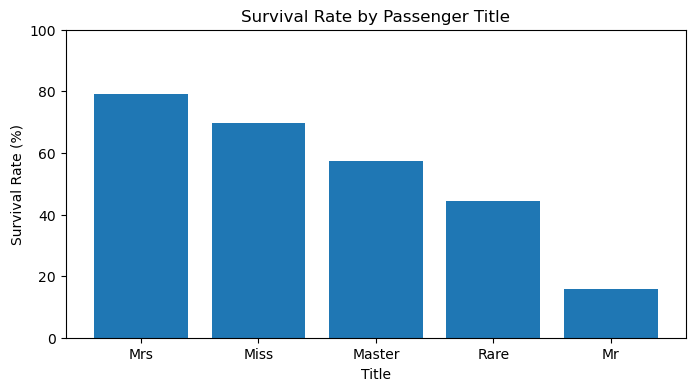

Title
Mrs       79.200000
Miss      69.780220
Master    57.500000
Rare      44.444444
Mr        15.667311
Name: Survived, dtype: float64

In [ ]:
title_survival = (
    train_features.groupby("Title")["Survived"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8, 4))
plt.bar(title_survival.index, title_survival.values)
plt.title("Survival Rate by Passenger Title")
plt.xlabel("Title")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

title_survival

## 6. Select Features and Target

We will not use columns such as:

- `PassengerId`, because it is only an identifier;
- `Name`, because useful features have already been extracted from it;
- `Ticket`, because it contains many different text values;
- `Cabin`, because it has a large number of missing values.

The target variable is `Survived`.


In [ ]:
feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "Title",
    "NameLength",
    "FamilySize",
    "IsAlone"
]

X = train_features[feature_columns]
y = train_features["Survived"]

X.head()

,Pclass,Sex,Age,Fare,Embarked,Title,NameLength,FamilySize,IsAlone
0,3,male,22.0,7.2500,S,Mr,23,2,0
1,1,female,38.0,71.2833,C,Mrs,51,2,0
2,3,female,26.0,7.9250,S,Miss,22,1,1
3,1,female,35.0,53.1000,S,Mrs,44,2,0
4,3,male,35.0,8.0500,S,Mr,24,1,1


## 7. Train-Validation Split

The original labelled dataset is divided into:

- **training data**, used to teach the model;
- **validation data**, used to evaluate the trained model.

We use 80% of the labelled data for training and 20% for validation.

`stratify=y` keeps approximately the same proportion of survived and non-survived passengers in both subsets.


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Validation features:", X_valid.shape)

Training features: (712, 9)
Validation features: (179, 9)


## 8. Preprocessing

The selected columns are divided into two groups.

### Numerical columns

Numerical columns contain measurable values such as age and fare.

We will:

1. replace missing values with the median;
2. apply `StandardScaler`.

Standard scaling transforms values using:

\[
z = \frac{x - \mu}{\sigma}
\]

where:

- \(x\) is the original value;
- \(\mu\) is the mean;
- \(\sigma\) is the standard deviation.

After scaling, numerical features are placed on a similar scale.

### Categorical columns

Categorical columns contain labels such as `male`, `female`, `S`, `C`, and `Q`.

We will:

1. replace missing values with the most frequent category;
2. apply one-hot encoding.

One-hot encoding creates a separate binary column for each category. For example, `Sex` may become columns such as `Sex_male` and `Sex_female`.


In [ ]:
numerical_columns = [
    "Pclass",
    "Age",
    "Fare",
    "NameLength",
    "FamilySize",
    "IsAlone"
]

categorical_columns = [
    "Sex",
    "Embarked",
    "Title"
]

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Pclass', 'Age', 'Fare', 'NameLength',
                                  'FamilySize', 'IsAlone']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex', 'Embarked', 'Title'])])

## 9. Logistic Regression Model

Logistic Regression is a classification algorithm.

It calculates the probability that a passenger belongs to class `1`, meaning survived. The probability is then converted into a class prediction.

A Scikit-learn `Pipeline` performs preprocessing and model training in one organised workflow. This also helps prevent data leakage.


In [ ]:
logistic_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_valid)

### Evaluate Logistic Regression

We use:

- **Accuracy**: percentage of correct predictions;
- **Confusion matrix**: number of correct and incorrect predictions for each class;
- **Precision**: how many predicted survivors actually survived;
- **Recall**: how many actual survivors were correctly identified;
- **F1-score**: balance between precision and recall.


In [ ]:
logistic_accuracy = accuracy_score(y_valid, logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, logistic_predictions))
print("\nClassification Report:")
print(classification_report(y_valid, logistic_predictions))

Logistic Regression Accuracy: 0.8379888268156425

Confusion Matrix:
[[98 12]
 [17 52]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



## 10. Random Forest Model

Random Forest is an ensemble machine learning algorithm.

It creates many decision trees using different samples and features. The final classification is based on voting across the trees.

Random Forest can model more complex and non-linear relationships than Logistic Regression.


In [ ]:
random_forest_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_valid)

### Evaluate Random Forest

In [ ]:
random_forest_accuracy = accuracy_score(
    y_valid,
    random_forest_predictions
)

print("Random Forest Accuracy:", random_forest_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, random_forest_predictions))
print("\nClassification Report:")
print(classification_report(y_valid, random_forest_predictions))

Random Forest Accuracy: 0.8212290502793296

Confusion Matrix:
[[97 13]
 [19 50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



## 11. Compare the Models

The model with higher validation accuracy performed better on this particular split. However, accuracy should not be the only measure considered.


In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        random_forest_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.837989
1,Random Forest,0.821229


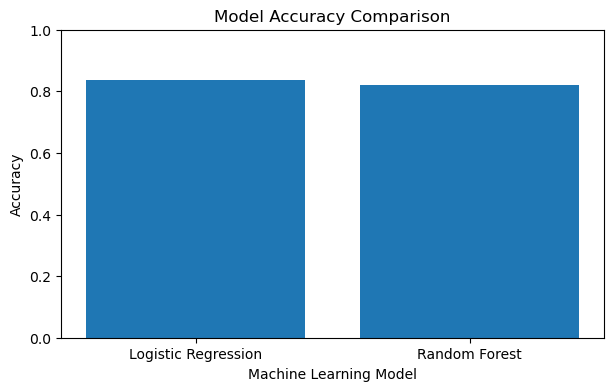

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(model_results["Model"], model_results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## 12. Train the Selected Model on All Training Data

After comparing the models, we can select one model and train it using all labelled records.

The following code automatically selects the model with the higher validation accuracy.


In [ ]:
if random_forest_accuracy >= logistic_accuracy:
    final_model = random_forest_model
    selected_model_name = "Random Forest"
else:
    final_model = logistic_model
    selected_model_name = "Logistic Regression"

final_model.fit(X, y)

print("Selected model:", selected_model_name)

Selected model: Logistic Regression


## 13. Make Predictions for the Kaggle Test Dataset

The test dataset is passed through the same feature-engineering and preprocessing steps.

The resulting `submission.csv` file contains:

- `PassengerId`;
- predicted `Survived` class.


In [ ]:
len(test_features)

418

In [ ]:
X_test_final = test_features[feature_columns]

test_predictions = final_model.predict(X_test_final)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
submission.to_csv("submission.csv", index=False)

print("submission.csv has been created successfully.")

# Summary

In this notebook, we:

1. loaded the train and test datasets;
2. explored the data using Pandas;
3. checked descriptive statistics and missing values;
4. visualised survival patterns with Matplotlib;
5. extracted titles and other useful features from passenger names;
6. separated numerical and categorical features;
7. replaced missing numerical and categorical values;
8. applied standard scaling to numerical columns;
9. applied one-hot encoding to categorical columns;
10. trained Logistic Regression and Random Forest models;
11. evaluated and compared the models;
12. created predictions for the Titanic test dataset.
